In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Sample data
x = np.array([1, 2, 3, 4, 5])
y = np.array([3.5, 5.5, 6.5, 9.5, 10.5])



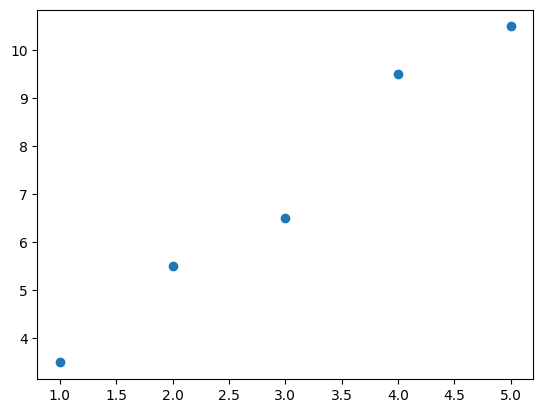

In [ ]:
plt.scatter(x, y)
plt.show()

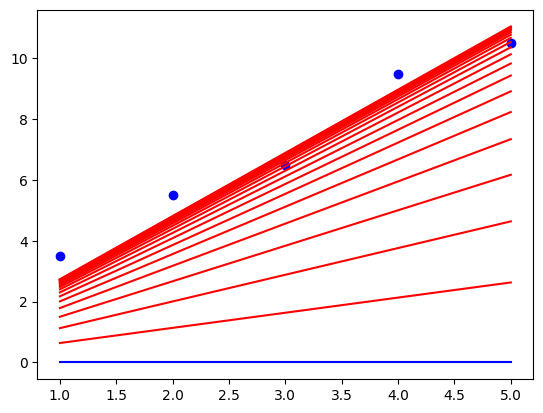

In [ ]:
# Initialize parameters
w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 100

losses = []
plt.scatter(x, y, color='blue')
plt.plot(x, w * x + b, color='blue')
# Gradient Descent Loop
for epoch in range(20):
    y_pred = w * x + b
    # loss = np.mean((y_pred - y) ** 2)

    dw = np.mean(2 * x * (y_pred - y))
    db = np.mean(2 * (y_pred - y))

    w = w - 0.01 * dw
    b = b - 0.01 * db

    plt.plot(x, w * x + b, color='red')

# **With Pytorch based Gradient Descent**

In [ ]:
import torch


In [ ]:
x = torch.tensor([5.0], dtype=torch.float32, requires_grad=True)



In [ ]:
x

tensor([5.], requires_grad=True)

In [ ]:
y = torch.log(x**2)



In [ ]:
y.backward() # => dy/dx + dy/dz + dy/k + ...



In [ ]:
x.grad # => dy/dx

tensor([0.4000])

In [ ]:
torch.randn(5)

tensor([ 1.0200,  0.4289,  0.1332, -0.3358,  1.1922])

# **Using Tensorflow**

In [ ]:
import tensorflow as tf



In [ ]:
# Data - convert to float tensors
x_tf = tf.constant([1, 2, 3, 4, 5], dtype=tf.float32)
y_tf = tf.constant([3.5, 5.5, 6.5, 9.5, 10.5], dtype=tf.float32)



In [ ]:
# Initialize weights and bias (use tf.Variable to track gradients)
w_tf = tf.Variable(tf.random.normal([1]))
b_tf = tf.Variable(tf.random.normal([1]))



In [ ]:
w_tf

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.00187644], dtype=float32)>

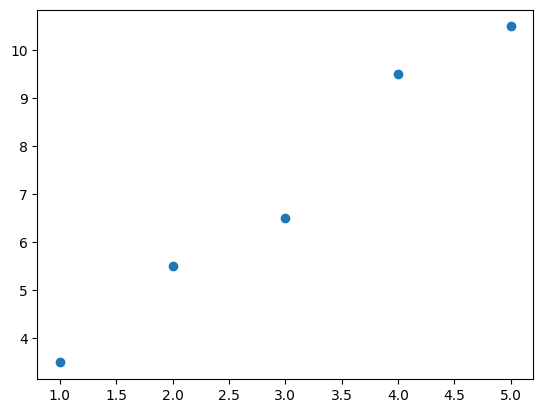

In [ ]:
plt.scatter(x_tf, y_tf)

# **Gradient Descent using tensor flow**

Epoch 0: Loss = 70.7127, w = 0.5485, b = -0.7312

Trained model: y = 2.29x + -0.12


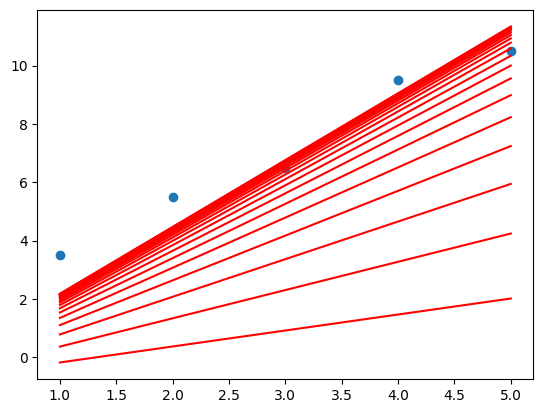

In [ ]:
# Initialize weights and bias (use tf.Variable to track gradients)
w_tf = tf.Variable(tf.random.normal([1]))
b_tf = tf.Variable(tf.random.normal([1]))

# Hyperparameters
lr = 0.01
epochs_tf = 20

# For plotting
plt.scatter(x_tf.numpy(), y_tf.numpy())

# Gradient Descent Loop
for epoch in range(epochs_tf):
    with tf.GradientTape() as tape:
        # Forward pass
        y_pred_tf = w_tf * x_tf + b_tf

        # Compute loss (MSE)
        loss_tf = tf.reduce_mean(tf.square(y_pred_tf - y_tf))

        # Calculate gradients
        gradients = tape.gradient(loss_tf, [w_tf, b_tf])

    # Update weights manually (using assign for in-place update)
    w_tf.assign_sub(lr * gradients[0])
    b_tf.assign_sub(lr * gradients[1])

    # Detach tensors before plotting to avoid the error
    plt.plot(x_tf.numpy(), (w_tf * x_tf + b_tf).numpy(), color='red')
# Logging
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss_tf.numpy():.4f}, w = {w_tf.numpy()[0]:.4f}, b = {b_tf.numpy()[0]:.4f}")

print(f"\nTrained model: y = {w_tf.numpy()[0]:.2f}x + {b_tf.numpy()[0]:.2f}")

plt.show()

# **Gradient Descent using Pytorch functions**

In [ ]:
X = torch.tensor([1, 2, 3, 4, 5], dtype=torch.float32)



In [ ]:
Y = torch.tensor([3.5,  5.5,  6.5,  9.5, 10.5], dtype=torch.float32)


In [ ]:

import torch
import torch.nn as nn
from torch.optim import SGD, Adam

In [ ]:
class NNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Linear(1,1)

    def forward(self, x):
        return self.first(x)

In [ ]:
modelob = NNModel()


In [ ]:
lssfn = nn.MSELoss()
optim = SGD(modelob.parameters(), lr=0.01)


In [ ]:
X = X.view(-1,1)

In [ ]:
Y = Y.view(-1,1)


In [ ]:
# modelob(X)

In [ ]:

for epoch in range(20):
    optim.zero_grad()
    y_pred = modelob(X)
    loss = lssfn(y_pred, Y)
    loss.backward()
    optim.step()
    print(loss.item())

76.76126098632812
44.806697845458984
26.18511390686035
15.33332347869873
9.009391784667969
5.324068546295166
3.1763970851898193
1.9247928857803345
1.1953723430633545
0.7702547311782837
0.5224713087081909
0.3780292570590973
0.2938099801540375
0.24468526244163513
0.2160123586654663
0.19925852119922638
0.18945050239562988
0.18369048833847046
0.18028955161571503
0.17826421558856964


In [ ]:
modelob.named_parameters()

<generator object Module.named_parameters at 0x7fa88ad43640>

In [ ]:
for name, param in modelob.named_parameters():
    print(name, param.data.item())

first.weight 1.869696021080017
first.bias 1.4053242206573486


# **Using Data Loader**

In [ ]:
from torch.utils.data import DataLoader


In [ ]:
# X.shape



In [ ]:
Y_reshaped = Y.view(-1, 1)

batch_dataloader = DataLoader(list(zip(X, Y_reshaped)), batch_size=2, shuffle=True)


In [ ]:
modelob_batch = NNModel()

In [ ]:
lssfn_batch = nn.MSELoss()
optim_batch = SGD(modelob_batch.parameters(), lr=0.01)


In [ ]:
for epoch in range(20):
    total_loss = 0
    for batch_X, batch_Y in batch_dataloader:
        optim_batch.zero_grad()
        y_pred_batch = modelob_batch(batch_X)
        loss_batch = lssfn_batch(y_pred_batch, batch_Y)
        loss_batch.backward()
        optim_batch.step()
        total_loss += loss_batch.item()
    print(total_loss / len(batch_dataloader))


36.110023498535156
5.349910577138265
1.0428747534751892
0.46181778128569323
0.34563766916592914
0.31204355756441754
0.3170334994792938
0.3081987003485362
0.31468166907628375
0.33816511432329815
0.31386541326840717
0.29566677411397296
0.3026788930098216
0.3107239107290904
0.3337918569644292
0.2812251349290212
0.32976894577344257
0.33851047853628796
0.2905116379261017
0.2769339879353841


In [ ]:
for name, param in modelob_batch.named_parameters():
    if param.requires_grad:
        print(name, param.data.numpy())

first.weight [[2.0364661]]
first.bias [0.9618745]
